Dự đoán khả năng trả nợ của khách hàng

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl as op

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, accuracy_score

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

Data Cleaning

In [2]:
df = pd.read_csv("../Data/accepted_2007_to_2018Q4.csv")

print(df.head())
print(df.info())

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amount disbursement_

In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,dti,fico_range_low,fico_range_high,inq_last_6mths,...,sec_app_collections_12_mths_ex_med,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,1.048563e+06,1.048563e+06,1.048563e+06,1.048563e+06,1.048563e+06,1.047707e+06,1.048563e+06,1.048563e+06,1.048560e+06,...,54916.000000,6112.0,6112.000000,6112.0,6112.000000,4882.000000,6112.000000,18709.000000,18709.000000,18709.000000
mean,NaN,1.525010e+04,1.525008e+04,1.524465e+04,1.277206e+01,4.477775e+02,1.932870e+01,6.981973e+02,7.021947e+02,5.239586e-01,...,0.074969,3.0,149.944000,3.0,13.751145,442.292636,11373.446041,5046.343797,47.800842,13.782939
std,NaN,9.227339e+03,9.227341e+03,9.225066e+03,4.853020e+00,2.669758e+02,1.483840e+01,3.306644e+01,3.309554e+01,8.218733e-01,...,0.394082,0.0,128.619238,0.0,9.670893,377.751498,7594.447952,3697.810115,6.477393,7.704838
min,NaN,1.000000e+03,1.000000e+03,7.500000e+02,5.310000e+00,1.401000e+01,-1.000000e+00,6.600000e+02,0.000000e+00,0.000000e+00,...,0.000000,3.0,0.640000,3.0,0.000000,1.920000,55.730000,107.000000,0.450000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.170000e+00,2.541700e+02,1.220000e+01,6.700000e+02,6.740000e+02,0.000000e+00,...,0.000000,3.0,54.737500,3.0,5.000000,162.067500,5406.835000,2211.000000,45.000000,8.000000
50%,NaN,1.320000e+04,1.320000e+04,1.320000e+04,1.229000e+01,3.797600e+02,1.827000e+01,6.900000e+02,6.940000e+02,0.000000e+00,...,0.000000,3.0,114.150000,3.0,15.000000,340.950000,9700.290000,4216.000000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.559000e+01,5.955250e+02,2.515000e+01,7.150000e+02,7.190000e+02,1.000000e+00,...,0.000000,3.0,207.630000,3.0,22.000000,606.727500,15820.962500,6910.160000,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,9.990000e+02,8.450000e+02,8.500000e+02,1.700000e+01,...,18.000000,3.0,943.940000,3.0,32.000000,2680.890000,40306.410000,30000.000000,166.670000,118.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Columns: 151 entries, id to settlement_term
dtypes: float64(105), object(9), str(37)
memory usage: 1.4+ GB


In [6]:
df.shape

(1048575, 151)

In [3]:
#check null
print(df.isnull().sum())

print(df.columns)


id                             0
member_id                1048575
loan_amnt                     12
funded_amnt                   12
funded_amnt_inv               12
                          ...   
settlement_status        1029866
settlement_date          1029866
settlement_amount        1029866
settlement_percentage    1029866
settlement_term          1029866
Length: 151, dtype: int64
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=151)


In [4]:
df.isnull().sum().sort_values(ascending=False).head(10)

member_id                                     1048575
desc                                          1048514
orig_projected_additional_accrued_interest    1043693
hardship_payoff_balance_amount                1042463
hardship_loan_status                          1042463
hardship_length                               1042463
hardship_type                                 1042463
payment_plan_start_date                       1042463
hardship_start_date                           1042463
hardship_status                               1042463
dtype: int64

##Drop columns with > 70% missing value

In [5]:
#drop những cột missing cao
missing = df.isnull().mean()
drop_cols = missing[missing > 0.7].index.tolist()
df.drop(columns=drop_cols, inplace=True)

##Drop Irrelevant Columns (ID, URLs, Descriptions, etc.)

In [6]:
irrelevant_cols = [
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'application_type',
    'policy_code', 'emp_title', 'pymnt_plan'
]
df.drop(columns=[col for col in irrelevant_cols if col in df.columns], inplace=True)


In [7]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       ...
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit', 'hardship_flag', 'disbursement_method',
       'debt_settlement_flag'],
      dtype='str', length=102)

##Filter to Only Loans with Outcome

In [8]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
0,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,...,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N
1,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,...,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N
2,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,...,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N
4,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,...,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N
5,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,...,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N


In [9]:
df['loan_status'].value_counts(dropna=False)

loan_status
Fully Paid     482594
Charged Off    129186
Name: count, dtype: int64

##Create Binary Target Variable

In [10]:
df['loan_default'] = df['loan_status'].apply(lambda x: 1 if x == 'Charged Off' else 0)
df.drop(columns=['loan_status'], inplace=True)

##Convert Columns 

In [11]:
# ---------- 1. Clean + convert issue_d ----------
df['issue_d'] = df['issue_d'].replace(['Charged Off', 'Fully Paid'], np.nan)
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%y', errors='coerce')

# ---------- 2. Clean + convert các cột date khác ----------
date_cols = ['last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d']

for col in date_cols:
    if col in df.columns:
        df[col] = df[col].replace(['Charged Off', 'Fully Paid'], np.nan)
        df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')

# ---------- 3. Extract feature từ issue_d ----------
df['issue_year'] = df['issue_d'].dt.year
df['issue_month'] = df['issue_d'].dt.month

# ---------- 4. Drop issue_d----------
df.drop(columns=['issue_d'], inplace=True)
#drop next_pymnt_d vì cột này NaN do là nó chỉ xuất hiện khi khác 2 trạng thái 'Charged Off', 'Fully Paid'
df.drop(columns=['next_pymnt_d'], inplace=True, errors='ignore')
# ---------- 5. Verify ----------
print(df[['issue_year', 'issue_month']].head())


   issue_year  issue_month
0        2015           12
1        2015           12
2        2015           12
4        2015           12
5        2015           12


In [ ]:
### ---------- 1. Convert emp_length to numeric ----------
def parse_emp_length(val):
    if pd.isnull(val):
        return np.nan
    if val == '< 1 year':
        return 0
    elif val == '10+ years':
        return 10
    else:
        return int(val.strip().split()[0])

df['emp_length'] = df['emp_length'].apply(parse_emp_length)

### ---------- 2. Convert term to integer ----------
df['term'] = df['term'].str.extract('(\d+)').astype(int)




##Fix object columns

In [13]:
# Handle int_rate
if df['int_rate'].dtype == 'object':
    df['int_rate'] = df['int_rate'].str.rstrip('%').astype(float)

# Handle revol_util
if 'revol_util' in df.columns and df['revol_util'].dtype == 'object':
    df['revol_util'] = df['revol_util'].str.rstrip('%').astype(float)

##Impute Remaining Missing Values (Median or Category)

In [14]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
df.isnull().sum().sort_values(ascending=False).head(10)

last_pymnt_d          1096
last_credit_pull_d      12
funded_amnt_inv          0
term                     0
int_rate                 0
loan_amnt                0
installment              0
grade                    0
emp_length               0
sub_grade                0
dtype: int64

##Check null row

In [16]:
print(df.isnull().sum())

print(df.columns)

loan_amnt               0
funded_amnt             0
funded_amnt_inv         0
term                    0
int_rate                0
                       ..
disbursement_method     0
debt_settlement_flag    0
loan_default            0
issue_year              0
issue_month             0
Length: 102, dtype: int64
Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       ...
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit', 'hardship_flag', 'disbursement_method',
       'debt_settlement_flag', 'loan_default', 'issue_year', 'issue_month'],
      dtype='str', length=102)


##Check Duplicates

In [18]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [19]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_default,issue_year,issue_month
0,3600.0,3600.0,3600.0,36,13.99,123.03,C,C4,10.0,MORTGAGE,...,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0,2015,12
1,24700.0,24700.0,24700.0,36,11.99,820.28,C,C1,10.0,MORTGAGE,...,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0,2015,12
2,20000.0,20000.0,20000.0,60,10.78,432.66,B,B4,10.0,MORTGAGE,...,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0,2015,12
4,10400.0,10400.0,10400.0,60,22.45,289.91,F,F1,3.0,MORTGAGE,...,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0,2015,12
5,11950.0,11950.0,11950.0,36,13.44,405.18,C,C3,4.0,RENT,...,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0,2015,12


##Biểu đồ tương quan

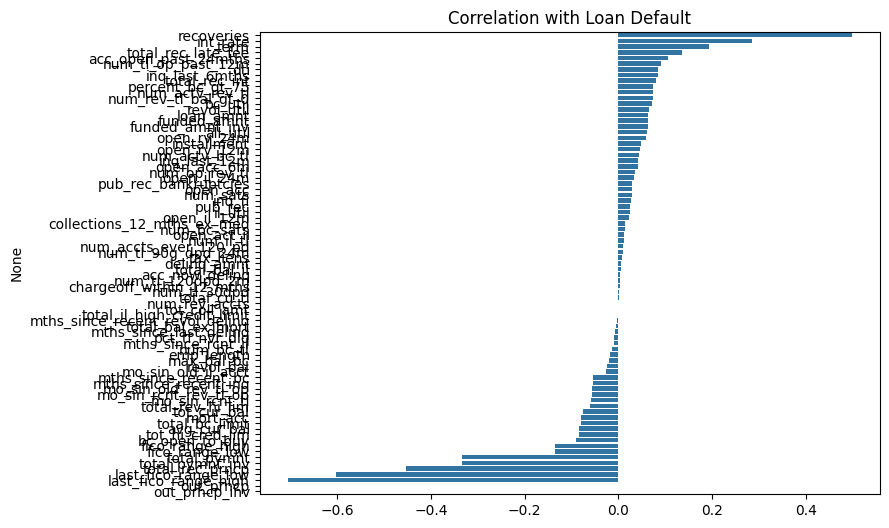

In [22]:
corr_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = corr_df.corr()

target_corr = correlation_matrix['loan_default'].sort_values(ascending=False)

# bỏ chính nó (self-correlation)
target_corr = target_corr.drop('loan_default')

plt.figure(figsize=(8,6))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Correlation with Loan Default")
plt.show()


In [24]:
print(target_corr.head(10))


recoveries              0.498293
int_rate                0.285595
term                    0.193844
total_rec_late_fee      0.136086
acc_open_past_24mths    0.106564
num_tl_op_past_12m      0.090402
dti                     0.085265
inq_last_6mths          0.083920
total_rec_int           0.081233
percent_bc_gt_75        0.074349
Name: loan_default, dtype: float64


##Drop data leak

In [23]:
leakage_cols = [
    'recoveries',
    'collection_recovery_fee',
    'total_rec_late_fee',
    'total_rec_int',
    'last_pymnt_d', 
    'last_credit_pull_d'
]

df = df.drop(columns=leakage_cols)


##Create Clean dataset

In [26]:
df.to_csv("cleaned_lendingclub.csv", index=False)

In [25]:
df = pd.read_csv("../Data/cleaned_lendingclub.csv")

print(df.head())
print(df.info())

   loan_amnt  funded_amnt  funded_amnt_inv  term  int_rate  installment grade  \
0     3600.0       3600.0           3600.0    36     13.99       123.03     C   
1    24700.0      24700.0          24700.0    36     11.99       820.28     C   
2    20000.0      20000.0          20000.0    60     10.78       432.66     B   
3    10400.0      10400.0          10400.0    60     22.45       289.91     F   
4    11950.0      11950.0          11950.0    36     13.44       405.18     C   

  sub_grade  emp_length home_ownership  ...  tot_hi_cred_lim  \
0        C4        10.0       MORTGAGE  ...         178050.0   
1        C1        10.0       MORTGAGE  ...         314017.0   
2        B4        10.0       MORTGAGE  ...         218418.0   
3        F1         3.0       MORTGAGE  ...         439570.0   
4        C3         4.0           RENT  ...          16900.0   

  total_bal_ex_mort total_bc_limit total_il_high_credit_limit  hardship_flag  \
0            7746.0         2400.0              

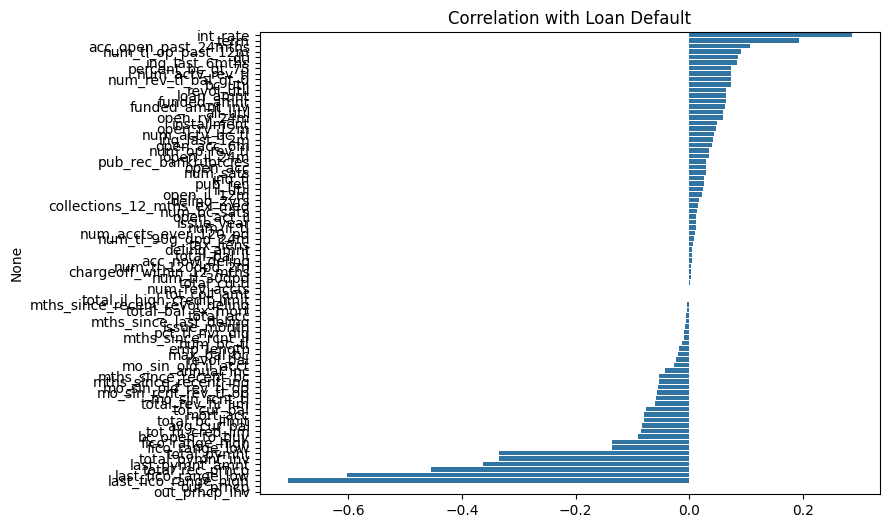

In [28]:
corr_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = corr_df.corr()

target_corr = correlation_matrix['loan_default'].sort_values(ascending=False)

# bỏ chính nó (self-correlation)
target_corr = target_corr.drop('loan_default')

plt.figure(figsize=(8,6))
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title("Correlation with Loan Default")
plt.show()

In [29]:
print(target_corr.head(10))

int_rate                0.285595
term                    0.193844
acc_open_past_24mths    0.106564
num_tl_op_past_12m      0.090402
dti                     0.085265
inq_last_6mths          0.083920
percent_bc_gt_75        0.074349
num_actv_rev_tl         0.074283
num_rev_tl_bal_gt_0     0.073434
bc_util                 0.072857
Name: loan_default, dtype: float64
